# Hacia el agua limpia para todos: Parte 3 y Parte 4

Este notebook consume el subconjunto congelado por Partes 1 y 2 y estudia kernels cuánticos de fidelidad con `pytket`.

La entrada vigente usa cinco variables de `chem5_v01`:

```text
Sulfate, ph, Conductivity, Chloramines, Hardness
```

El cambio reemplaza `Solids` por `Conductivity`. Los resultados cuánticos obtenidos con el conjunto anterior quedan invalidados para comparación directa y deben regenerarse.


## Referencias de TKET usadas

La implementacion sigue la documentacion oficial de Quantinuum TKET:

- `Circuit`, `get_statevector()`, `depth()`, `n_gates`, `n_2qb_gates()`: https://docs.quantinuum.com/tket/api-docs/circuit_class.html
- visualizacion HTML de circuitos: https://docs.quantinuum.com/tket/api-docs/display.html
- QASM export/import: https://docs.quantinuum.com/tket/api-docs/qasm.html
- passes, rebases y descomposicion de cajas: https://docs.quantinuum.com/tket/api-docs/passes.html
- gate set nativo de Quantinuum con `Rz`, `PhasedX`, `ZZPhase`/`ZZMax`: https://docs.quantinuum.com/tket/extensions/pytket-quantinuum/index.html

0. Verificacion del entorno en Colab
Si aparece AttributeError: module 'numpy._core._multiarray_umath' has no attribute '_blas_supports_fpe', el problema es una mezcla incompatible entre numpy, scipy y scikit-learn en la sesion, no el codigo del kernel. Ejecuta desde arriba: esta celda detecta ese estado, reinstala un stack compatible en Colab y detiene la ejecucion para que reinicies el runtime antes de continuar.

In [4]:
# 1. Dependencias reproducibles para Google Colab
import sys
import subprocess

IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    subprocess.check_call([
        sys.executable, "-m", "pip", "install", "-q",
        "scikit-learn==1.6.1",
        "imbalanced-learn==0.14.2",
        "pytket==2.18.1",
        "joblib>=1.4,<2",
        "scipy==1.15.3",
        "pandas==2.2.3",
        "matplotlib==3.10.0",
    ])

In [5]:
import os
from pathlib import Path

# TKET intenta crear su configuracion en ~/.config. En este entorno restringido
# la fijamos dentro del workspace antes de importar pytket.
WORKDIR = Path.cwd().resolve()
os.environ.setdefault("XDG_CONFIG_HOME", str(WORKDIR / ".pytket_config"))
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "8")

# Ensure the pytket config directory exists before pytket is imported.
pytket_config_path = Path(os.environ["XDG_CONFIG_HOME"]) / "pytket"
pytket_config_path.mkdir(parents=True, exist_ok=True)

import itertools
import json
import time
import warnings
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import HTML, Markdown, display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_score,
    recall_score,
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

import pytket
from pytket import Circuit, OpType
from pytket.circuit import PauliExpBox
from pytket.circuit.display import get_circuit_renderer, render_circuit_jupyter
from pytket.pauli import Pauli
from pytket.passes import AutoRebase, DecomposeBoxes, FullPeepholeOptimise, RemoveRedundancies, SequencePass
from pytket.qasm import circuit_to_qasm_str

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

TARGET = "Potability"
CLASS_LABELS = [0, 1]
CLASS_NAMES = {0: "No potable", 1: "Potable"}
C_GRID = [0.1, 1.0, 10.0]
SHOTS_GRID = [256, 1024, 4096]
NOISE_LEVELS = [0.01, 0.03, 0.05]
N_SHOT_REPEATS = 20
RNG_SEED = 20260831

from google.colab import drive
drive.mount("/content/drive", force_remount=False)
PROJECT_ROOT = Path("/content/drive/MyDrive/Colab Notebooks")

PART12_DIR = PROJECT_ROOT / "artifacts_v1_2"
ARTIFACT_DIR = PROJECT_ROOT / "artifacts_v3_4"
FIGURE_DIR = ARTIFACT_DIR / "figures"
CIRCUIT_DIR = ARTIFACT_DIR / "circuits"
KERNEL_DIR = ARTIFACT_DIR / "kernels"
for path in [ARTIFACT_DIR, FIGURE_DIR, CIRCUIT_DIR, KERNEL_DIR]:
    path.mkdir(parents=True, exist_ok=True)

print("pytket:", pytket.__version__)
print("Parte 1/2 artifacts:", PART12_DIR)
print("Parte 3/4 artifacts:", ARTIFACT_DIR)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
pytket: 2.18.1
Parte 1/2 artifacts: /content/drive/MyDrive/Colab Notebooks/artifacts_v1_2
Parte 3/4 artifacts: /content/drive/MyDrive/Colab Notebooks/artifacts_v3_4


## 1. Entrada desde Parte 1 y Parte 2

Usamos el subconjunto balanceado de 80 muestras y sus folds congelados. Las cinco variables de `chem5_v01` reducen el experimento a cinco qubits:

```text
Sulfate, ph, Conductivity, Chloramines, Hardness
```

El notebook valida explícitamente este contrato para impedir que se ejecuten circuitos con artefactos antiguos basados en `Solids`.


In [6]:
quantum80_raw = pd.read_csv(PART12_DIR / "quantum80_raw.csv")
quantum80_selected = pd.read_csv(PART12_DIR / "quantum80_selected_features.csv")
quantum80_folds = pd.read_csv(PART12_DIR / "quantum80_folds.csv")
with (PART12_DIR / "quantum80_manifest.json").open("r", encoding="utf-8") as f:
    part12_manifest = json.load(f)

FEATURES = part12_manifest["features"]
EXPECTED_FEATURE_SET = "chem5_v01"
EXPECTED_FEATURES = ["Sulfate", "ph", "Conductivity", "Chloramines", "Hardness"]

if part12_manifest.get("feature_set") != EXPECTED_FEATURE_SET:
    raise ValueError(
        f"Se esperaba feature_set={EXPECTED_FEATURE_SET}, pero el manifiesto contiene "
        f"{part12_manifest.get('feature_set')}. Reejecutar Partes 1 y 2."
    )
if FEATURES != EXPECTED_FEATURES:
    raise ValueError(
        f"Orden/variables incompatibles. Esperado: {EXPECTED_FEATURES}; recibido: {FEATURES}. "
        "Reejecutar Partes 1 y 2 para regenerar artifacts_v1."
    )

selected_feature_columns = [
    column for column in quantum80_selected.columns
    if column not in {"source_index", TARGET}
]
if selected_feature_columns != EXPECTED_FEATURES:
    raise ValueError(
        "El CSV quantum80_selected_features.csv no coincide con chem5_v01. "
        f"Esperado: {EXPECTED_FEATURES}; recibido: {selected_feature_columns}."
    )
if "Solids" in quantum80_selected.columns:
    raise ValueError(
        "Artifact obsoleto detectado: quantum80_selected_features.csv todavía contiene Solids. "
        "Reejecutar Partes 1 y 2 con la selección bloqueada chem5_v01."
    )

N_QUBITS = len(FEATURES)

df_q = quantum80_selected.copy()
y = df_q[TARGET].astype(int).to_numpy()
folds = quantum80_folds["validation_fold"].astype(int).to_numpy()
source_index = df_q["source_index"].astype(int).to_numpy()

checks = {
    "rows": int(len(df_q)),
    "n_qubits": int(N_QUBITS),
    "class_counts": pd.Series(y).value_counts().sort_index().to_dict(),
    "fold_class_counts": (
        quantum80_folds.groupby(["validation_fold", TARGET]).size().rename("rows").reset_index().to_dict("records")
    ),
}
print(json.dumps(checks, indent=2))
display(df_q.head())

if len(df_q) != 80:
    raise ValueError("Se esperaban 80 muestras.")
if N_QUBITS != 5:
    raise ValueError("Se esperaban 5 features/qubits desde Parte 1/2.")
if set(checks["class_counts"].values()) != {40}:
    raise ValueError("El subconjunto no esta balanceado 40/40.")

{
  "rows": 80,
  "n_qubits": 5,
  "class_counts": {
    "0": 40,
    "1": 40
  },
  "fold_class_counts": [
    {
      "validation_fold": 0,
      "Potability": 0,
      "rows": 8
    },
    {
      "validation_fold": 0,
      "Potability": 1,
      "rows": 8
    },
    {
      "validation_fold": 1,
      "Potability": 0,
      "rows": 8
    },
    {
      "validation_fold": 1,
      "Potability": 1,
      "rows": 8
    },
    {
      "validation_fold": 2,
      "Potability": 0,
      "rows": 8
    },
    {
      "validation_fold": 2,
      "Potability": 1,
      "rows": 8
    },
    {
      "validation_fold": 3,
      "Potability": 0,
      "rows": 8
    },
    {
      "validation_fold": 3,
      "Potability": 1,
      "rows": 8
    },
    {
      "validation_fold": 4,
      "Potability": 0,
      "rows": 8
    },
    {
      "validation_fold": 4,
      "Potability": 1,
      "rows": 8
    }
  ]
}


,source_index,Sulfate,ph,Conductivity,Chloramines,Hardness,Potability
0,284,259.979966,7.958984,327.623881,9.537735,171.483625,1
1,3028,376.055637,5.369584,401.833036,8.065886,170.835192,0
2,2720,342.029115,5.945989,471.122125,7.894120,151.685797,1
3,875,374.226926,4.489784,518.585253,8.486030,188.251939,0
4,1341,239.911902,NaN,362.500414,6.951666,194.445316,0


## 2. Preprocesamiento para angulos

Para cada fold, las medianas por clase y el escalado se ajustan solo con las filas de entrenamiento del fold. Luego se transforma validacion con los parametros del training. Esto evita fuga en escalado y conserva el protocolo de imputacion por clase del planteamiento.

Los parametros de `pytket` estan en half-turns: `1.0` equivale a una rotacion de `pi` radianes. Por eso los escalados producen valores acotados aproximadamente en `[-1, 1]`.

In [7]:
def fit_class_medians(X: pd.DataFrame, y_values: np.ndarray) -> dict:
    y_series = pd.Series(np.asarray(y_values, dtype=int), index=X.index)
    return {
        "by_class": {
            int(cls): X.loc[y_series == cls].median(numeric_only=True)
            for cls in sorted(pd.unique(y_series))
        },
        "global": X.median(numeric_only=True),
    }


def transform_class_medians(X: pd.DataFrame, y_values: np.ndarray, stats: dict) -> pd.DataFrame:
    X_imp = X.copy()
    y_series = pd.Series(np.asarray(y_values, dtype=int), index=X.index)
    for cls, medians in stats["by_class"].items():
        idx = y_series == cls
        X_imp.loc[idx] = X_imp.loc[idx].fillna(medians)
    return X_imp.fillna(stats["global"])


def fit_angle_preprocessor(X_train_raw: pd.DataFrame, y_train_values: np.ndarray, features: list[str]) -> dict:
    medians = fit_class_medians(X_train_raw[features], y_train_values)
    X_train_imp = transform_class_medians(X_train_raw[features], y_train_values, medians)
    scaler = StandardScaler().fit(X_train_imp)
    z_train = scaler.transform(X_train_imp)
    z_min = z_train.min(axis=0)
    z_max = z_train.max(axis=0)
    return {"medians": medians, "scaler": scaler, "z_min": z_min, "z_max": z_max}


def transform_to_angles(
    X_raw: pd.DataFrame,
    y_values: np.ndarray,
    features: list[str],
    prep: dict,
    scaling: str,
) -> np.ndarray:
    X_imp = transform_class_medians(X_raw[features], y_values, prep["medians"])
    z = prep["scaler"].transform(X_imp)
    if scaling == "robust_atan":
        return (2.0 / np.pi) * np.arctan(z)
    if scaling == "minmax":
        denom = np.where(np.abs(prep["z_max"] - prep["z_min"]) < 1e-12, 1.0, prep["z_max"] - prep["z_min"])
        return np.clip(2.0 * (z - prep["z_min"]) / denom - 1.0, -1.0, 1.0)
    if scaling == "zscore_clip":
        return np.clip(z / 2.5, -1.0, 1.0)
    raise ValueError(f"Scaling no soportado: {scaling}")


def fit_transform_global_angles(df_input: pd.DataFrame, features: list[str], scaling: str) -> np.ndarray:
    prep = fit_angle_preprocessor(df_input, df_input[TARGET].to_numpy(dtype=int), features)
    return transform_to_angles(df_input, df_input[TARGET].to_numpy(dtype=int), features, prep, scaling)

## 3. Definición de mapas de características en `pytket`

Se implementan tres familias:

- `ZZFeatureMap`: rotaciones locales `Rz` y fases `ZZPhase` sobre pares.
- `PauliFeatureMap`: exponentiales de cadenas de Pauli mediante `PauliExpBox`.
- `custom_water_domain`: mapa personalizado con interacciones de dominio entre las variables de `chem5_v01`.

Cada mapa produce `|phi(x)> = U_phi(x)|0...0>` y el kernel exacto se calcula como fidelidad entre statevectors.

En el mapa de dominio, los pesos son **hiperparámetros heurísticos normalizados alrededor de 1**. Representan prioridad relativa dentro del circuito; no son coeficientes regulatorios, relaciones causales ni estimaciones químicas aprendidas.


In [8]:
PAULI_LOOKUP = {"X": Pauli.X, "Y": Pauli.Y, "Z": Pauli.Z}

# Pesos heurísticos del mapa de dominio. Se mantienen cercanos a 1 para
# evitar que una sola interacción domine el kernel antes de la ablación.
# Conductivity reemplaza a Solids y recibe la interacción más fuerte con
# Hardness porque ambas capturan dimensiones de la carga mineral/iónica.
DOMAIN_EDGES = [
    ("ph", "Sulfate", 1.10),
    ("Conductivity", "Hardness", 1.20),
    ("Chloramines", "Sulfate", 0.90),
    ("ph", "Hardness", 0.95),
    ("Chloramines", "Conductivity", 0.80),
]

@dataclass(frozen=True)
class MapConfig:
    name: str
    family: str
    scaling: str = "robust_atan"
    reps: int = 1
    topology: str = "linear"
    alpha: float = 0.8
    local_terms: tuple[str, ...] = ("Z",)
    pair_terms: tuple[str, ...] = ("ZZ",)
    data_reupload: bool = False


def topology_pairs(n_qubits: int, topology: str) -> list[tuple[int, int]]:
    if topology == "linear":
        return [(i, i + 1) for i in range(n_qubits - 1)]
    if topology == "ring":
        return [(i, i + 1) for i in range(n_qubits - 1)] + [(n_qubits - 1, 0)]
    if topology == "full":
        return list(itertools.combinations(range(n_qubits), 2))
    if topology == "domain":
        feature_to_pos = {feature: idx for idx, feature in enumerate(FEATURES)}
        return [(feature_to_pos[a], feature_to_pos[b]) for a, b, _ in DOMAIN_EDGES]
    raise ValueError(f"Topologia no soportada: {topology}")


def domain_weight(i: int, j: int) -> float:
    feature_to_pos = {feature: idx for idx, feature in enumerate(FEATURES)}
    for a, b, weight in DOMAIN_EDGES:
        ia, ib = feature_to_pos[a], feature_to_pos[b]
        if {i, j} == {ia, ib}:
            return weight
    return 1.0


def add_pauli_exp(circ: Circuit, pauli_string: str, qubits: list[int], angle_halfturns: float) -> None:
    paulis = [PAULI_LOOKUP[p] for p in pauli_string]
    circ.add_pauliexpbox(PauliExpBox(paulis, float(angle_halfturns)), qubits)


def build_feature_circuit(x_angles: np.ndarray, config: MapConfig) -> Circuit:
    x = np.asarray(x_angles, dtype=float)
    n = len(x)
    circ = Circuit(n)

    for q in range(n):
        circ.H(q)

    for rep in range(config.reps):
        rep_scale = config.alpha / np.sqrt(rep + 1)

        if config.family == "ZZFeatureMap":
            for i in range(n):
                circ.Rz(rep_scale * x[i], i)
            for i, j in topology_pairs(n, config.topology):
                circ.ZZPhase(rep_scale * x[i] * x[j], i, j)

        elif config.family == "PauliFeatureMap":
            for term in config.local_terms:
                for i in range(n):
                    add_pauli_exp(circ, term, [i], rep_scale * x[i])
            for term in config.pair_terms:
                if len(term) != 2:
                    raise ValueError("Este notebook solo usa terminos Pauli de pares de longitud 2.")
                for i, j in topology_pairs(n, config.topology):
                    add_pauli_exp(circ, term, [i, j], rep_scale * x[i] * x[j])

        elif config.family == "custom_water_domain":
            for i in range(n):
                circ.Ry(0.75 * rep_scale * x[i], i)
                circ.Rz(0.35 * rep_scale * np.sign(x[i]) * x[i] ** 2, i)
            for i, j in topology_pairs(n, "domain"):
                circ.ZZPhase(rep_scale * domain_weight(i, j) * x[i] * x[j], i, j)
            if config.data_reupload:
                for i in range(n):
                    circ.Rx(0.25 * rep_scale * x[i], i)
        else:
            raise ValueError(f"Familia no soportada: {config.family}")

    return circ


MAP_CONFIGS = [
    MapConfig("zz_linear_r1_robust", "ZZFeatureMap", scaling="robust_atan", reps=1, topology="linear", alpha=0.8),
    MapConfig("zz_ring_r1_robust", "ZZFeatureMap", scaling="robust_atan", reps=1, topology="ring", alpha=0.8),
    MapConfig("zz_full_r1_robust", "ZZFeatureMap", scaling="robust_atan", reps=1, topology="full", alpha=0.8),
    MapConfig("zz_ring_r2_robust", "ZZFeatureMap", scaling="robust_atan", reps=2, topology="ring", alpha=0.8),
    MapConfig("pauli_z_zz_linear_r1_robust", "PauliFeatureMap", scaling="robust_atan", reps=1, topology="linear", alpha=0.8, local_terms=("Z",), pair_terms=("ZZ",)),
    MapConfig("pauli_z_zz_ring_r1_robust", "PauliFeatureMap", scaling="robust_atan", reps=1, topology="ring", alpha=0.8, local_terms=("Z",), pair_terms=("ZZ",)),
    MapConfig("pauli_xz_xxzz_linear_r1_robust", "PauliFeatureMap", scaling="robust_atan", reps=1, topology="linear", alpha=0.55, local_terms=("X", "Z"), pair_terms=("XX", "ZZ")),
    MapConfig("pauli_z_zz_ring_r1_minmax", "PauliFeatureMap", scaling="minmax", reps=1, topology="ring", alpha=0.8, local_terms=("Z",), pair_terms=("ZZ",)),
    MapConfig("custom_water_domain_r1_robust", "custom_water_domain", scaling="robust_atan", reps=1, topology="domain", alpha=0.9, data_reupload=False),
    MapConfig("custom_water_domain_r2_reupload_robust", "custom_water_domain", scaling="robust_atan", reps=2, topology="domain", alpha=0.75, data_reupload=True),
]

display(pd.DataFrame([config.__dict__ for config in MAP_CONFIGS]))

,name,family,scaling,reps,topology,alpha,local_terms,pair_terms,data_reupload
0,zz_linear_r1_robust,ZZFeatureMap,robust_atan,1,linear,0.80,"(Z,)","(ZZ,)",False
1,zz_ring_r1_robust,ZZFeatureMap,robust_atan,1,ring,0.80,"(Z,)","(ZZ,)",False
2,zz_full_r1_robust,ZZFeatureMap,robust_atan,1,full,0.80,"(Z,)","(ZZ,)",False
3,zz_ring_r2_robust,ZZFeatureMap,robust_atan,2,ring,0.80,"(Z,)","(ZZ,)",False
4,pauli_z_zz_linear_r1_robust,PauliFeatureMap,robust_atan,1,linear,0.80,"(Z,)","(ZZ,)",False
5,pauli_z_zz_ring_r1_robust,PauliFeatureMap,robust_atan,1,ring,0.80,"(Z,)","(ZZ,)",False
6,pauli_xz_xxzz_linear_r1_robust,PauliFeatureMap,robust_atan,1,linear,0.55,"(X, Z)","(XX, ZZ)",False
7,pauli_z_zz_ring_r1_minmax,PauliFeatureMap,minmax,1,ring,0.80,"(Z,)","(ZZ,)",False
8,custom_water_domain_r1_robust,custom_water_domain,robust_atan,1,domain,0.90,"(Z,)","(ZZ,)",False
9,custom_water_domain_r2_reupload_robust,custom_water_domain,robust_atan,2,domain,0.75,"(Z,)","(ZZ,)",True


## 4. Utilidades para kernel, recursos y metricas

In [9]:
def statevectors_from_angles(X_angles: np.ndarray, config: MapConfig) -> np.ndarray:
    states = []
    for row in X_angles:
        states.append(build_feature_circuit(row, config).get_statevector())
    return np.asarray(states)


def fidelity_kernel_from_states(states_a: np.ndarray, states_b: np.ndarray | None = None) -> np.ndarray:
    if states_b is None:
        states_b = states_a
    overlaps = states_a @ states_b.conj().T
    K = np.abs(overlaps) ** 2
    return np.clip(K.real, 0.0, 1.0)


def symmetrize_kernel(K: np.ndarray) -> np.ndarray:
    K_sym = 0.5 * (K + K.T)
    np.fill_diagonal(K_sym, 1.0)
    return np.clip(K_sym, 0.0, 1.0)


def classification_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_LABELS)
    tn, fp, fn, tp = [int(v) for v in cm.ravel()]
    specificity = tn / (tn + fp) if (tn + fp) else np.nan
    return {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "precision": float(precision_score(y_true, y_pred, zero_division=0)),
        "recall": float(recall_score(y_true, y_pred, zero_division=0)),
        "specificity": float(specificity),
        "f1": float(f1_score(y_true, y_pred, zero_division=0)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
    }


def centered_matrix(A: np.ndarray) -> np.ndarray:
    n = A.shape[0]
    H = np.eye(n) - np.ones((n, n)) / n
    return H @ A @ H


def kernel_target_alignment(K: np.ndarray, labels: np.ndarray) -> float:
    y_signed = np.where(labels == 1, 1.0, -1.0)
    Y = np.outer(y_signed, y_signed)
    Kc = centered_matrix(K)
    Yc = centered_matrix(Y)
    denom = np.linalg.norm(Kc, "fro") * np.linalg.norm(Yc, "fro")
    return float(np.sum(Kc * Yc) / denom) if denom > 0 else np.nan


def kernel_geometry(K: np.ndarray, labels: np.ndarray) -> dict:
    labels = np.asarray(labels)
    n = len(labels)
    mask_off = ~np.eye(n, dtype=bool)
    same = (labels[:, None] == labels[None, :]) & mask_off
    diff = (labels[:, None] != labels[None, :])
    eigvals = np.linalg.eigvalsh(0.5 * (K + K.T))
    eig_pos = np.clip(eigvals, 0.0, None)
    eig_sum = eig_pos.sum()
    if eig_sum > 0:
        p = eig_pos / eig_sum
        p = p[p > 0]
        effective_rank = float(np.exp(-np.sum(p * np.log(p))))
    else:
        effective_rank = 0.0
    return {
        "alignment": kernel_target_alignment(K, labels),
        "intra_mean": float(K[same].mean()),
        "intra_std": float(K[same].std(ddof=1)),
        "inter_mean": float(K[diff].mean()),
        "inter_std": float(K[diff].std(ddof=1)),
        "intra_minus_inter": float(K[same].mean() - K[diff].mean()),
        "offdiag_mean": float(K[mask_off].mean()),
        "offdiag_std": float(K[mask_off].std(ddof=1)),
        "min_eigenvalue": float(eigvals.min()),
        "max_eigenvalue": float(eigvals.max()),
        "effective_rank": effective_rank,
        "near_uniform_score": float(K[mask_off].std(ddof=1)),
    }


def compile_native_like(circ: Circuit) -> Circuit:
    compiled = circ.copy()
    native_like = {OpType.Rz, OpType.PhasedX, OpType.ZZPhase}
    SequencePass([
        DecomposeBoxes(),
        FullPeepholeOptimise(),
        AutoRebase(native_like),
        RemoveRedundancies(),
    ]).apply(compiled)
    return compiled


def compile_qasm_portable(circ: Circuit) -> Circuit:
    compiled = circ.copy()
    portable = {OpType.H, OpType.Rx, OpType.Rz, OpType.CX}
    SequencePass([
        DecomposeBoxes(),
        AutoRebase(portable),
        RemoveRedundancies(),
    ]).apply(compiled)
    return compiled


def circuit_resources(config: MapConfig, x_angles: np.ndarray) -> dict:
    circ = build_feature_circuit(x_angles, config)
    native = compile_native_like(circ)
    portable = compile_qasm_portable(circ)
    return {
        "map": config.name,
        "family": config.family,
        "n_qubits": int(len(x_angles)),
        "raw_n_gates": int(circ.n_gates),
        "raw_depth": int(circ.depth()),
        "raw_2q_gates": int(circ.n_2qb_gates()),
        "raw_2q_depth": int(circ.depth_2q()),
        "native_n_gates": int(native.n_gates),
        "native_depth": int(native.depth()),
        "native_2q_gates": int(native.n_2qb_gates()),
        "native_2q_depth": int(native.depth_2q()),
        "portable_qasm_n_gates": int(portable.n_gates),
        "portable_qasm_2q_gates": int(portable.n_2qb_gates()),
    }


def evaluate_precomputed_kernel(K: np.ndarray, labels: np.ndarray, fold_ids: np.ndarray, C: float) -> tuple[pd.DataFrame, pd.DataFrame]:
    fold_rows = []
    pred_rows = []
    for fold in sorted(np.unique(fold_ids)):
        train_idx = np.flatnonzero(fold_ids != fold)
        valid_idx = np.flatnonzero(fold_ids == fold)
        svc = SVC(kernel="precomputed", C=C)
        svc.fit(K[np.ix_(train_idx, train_idx)], labels[train_idx])
        pred = svc.predict(K[np.ix_(valid_idx, train_idx)])
        row = {"fold": int(fold), "C": C, "n_train": int(len(train_idx)), "n_valid": int(len(valid_idx))}
        row.update(classification_metrics(labels[valid_idx], pred))
        fold_rows.append(row)
        pred_rows.append(pd.DataFrame({
            "fold": int(fold),
            "source_index": source_index[valid_idx],
            "y_true": labels[valid_idx],
            "y_pred": pred,
        }))
    return pd.DataFrame(fold_rows), pd.concat(pred_rows, ignore_index=True)


def summarize_fold_metrics(fold_df: pd.DataFrame) -> dict:
    summary = {}
    for metric in ["accuracy", "balanced_accuracy", "precision", "recall", "specificity", "f1", "mcc"]:
        summary[f"{metric}_mean"] = float(fold_df[metric].mean())
        summary[f"{metric}_std"] = float(fold_df[metric].std(ddof=1))
    return summary


def compute_fold_local_kernels(config: MapConfig) -> dict[int, tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]]:
    fold_kernels = {}
    X_all = df_q[FEATURES].copy()
    for fold in sorted(np.unique(folds)):
        train_idx = np.flatnonzero(folds != fold)
        valid_idx = np.flatnonzero(folds == fold)
        prep = fit_angle_preprocessor(X_all.iloc[train_idx], y[train_idx], FEATURES)
        X_train_angles = transform_to_angles(X_all.iloc[train_idx], y[train_idx], FEATURES, prep, config.scaling)
        X_valid_angles = transform_to_angles(X_all.iloc[valid_idx], y[valid_idx], FEATURES, prep, config.scaling)
        train_states = statevectors_from_angles(X_train_angles, config)
        valid_states = statevectors_from_angles(X_valid_angles, config)
        K_train = fidelity_kernel_from_states(train_states)
        K_valid_train = fidelity_kernel_from_states(valid_states, train_states)
        fold_kernels[int(fold)] = (K_train, K_valid_train, train_idx, valid_idx)
    return fold_kernels


def evaluate_map_fold_local(config: MapConfig) -> tuple[pd.DataFrame, pd.DataFrame]:
    fold_kernel_cache = compute_fold_local_kernels(config)
    fold_rows = []
    pred_rows = []
    for C in C_GRID:
        for fold, (K_train, K_valid_train, train_idx, valid_idx) in fold_kernel_cache.items():
            svc = SVC(kernel="precomputed", C=C)
            svc.fit(K_train, y[train_idx])
            pred = svc.predict(K_valid_train)
            row = {"map": config.name, "family": config.family, "C": C, "fold": int(fold), "scaling": config.scaling, "reps": config.reps, "topology": config.topology}
            row.update(classification_metrics(y[valid_idx], pred))
            fold_rows.append(row)
            pred_rows.append(pd.DataFrame({
                "map": config.name,
                "C": C,
                "fold": int(fold),
                "source_index": source_index[valid_idx],
                "y_true": y[valid_idx],
                "y_pred": pred,
            }))
    return pd.DataFrame(fold_rows), pd.concat(pred_rows, ignore_index=True)

## 5. Parte 3: kernel cuántico primario

El mapa primario de trabajo es `custom_water_domain_r1_robust`. Esta elección permite probar directamente el nuevo conjunto `chem5_v01` y las interacciones ponderadas que incorporan `Conductivity`.

El mapa sigue siendo una hipótesis experimental. Debido al cambio de variables, sus métricas anteriores no se reutilizan: deben recalcularse con los nuevos `quantum80_*`.


Numero de qubits: 5
Features/qubits: ['Sulfate', 'ph', 'Conductivity', 'Chloramines', 'Hardness']


,map,alignment,intra_mean,intra_std,inter_mean,inter_std,intra_minus_inter,offdiag_mean,offdiag_std,min_eigenvalue,max_eigenvalue,effective_rank,near_uniform_score,family,n_qubits,raw_n_gates,raw_depth,raw_2q_gates,raw_2q_depth,native_n_gates,native_depth,native_2q_gates,native_2q_depth,portable_qasm_n_gates,portable_qasm_2q_gates
0,custom_water_domain_r1_robust,0.048309,0.160366,0.179847,0.164001,0.178542,-0.003634,0.162206,0.179182,0.003776,15.914647,26.703147,0.179182,custom_water_domain,5,20,6,5,3,60,24,10,6,35,10


,map,C,accuracy_mean,balanced_accuracy_mean,f1_mean,mcc_mean
2,custom_water_domain_r1_robust,10.0,0.6250,0.6250,0.633333,0.254465
1,custom_water_domain_r1_robust,1.0,0.5500,0.5500,0.565046,0.105050
0,custom_water_domain_r1_robust,0.1,0.5125,0.5125,0.468974,0.042438


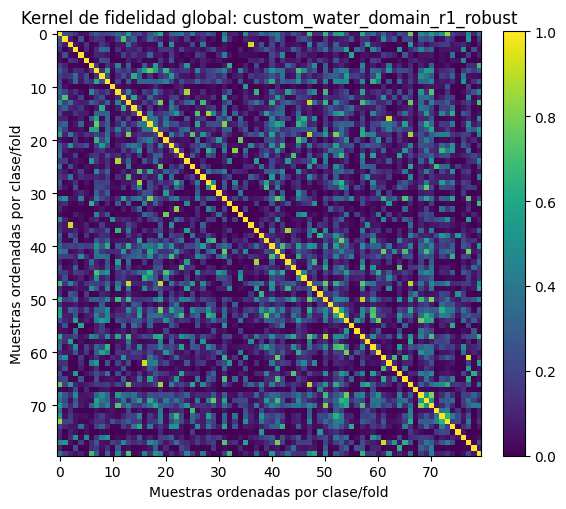

In [17]:
PRIMARY_NAME = "custom_water_domain_r1_robust"
primary_config = next(config for config in MAP_CONFIGS if config.name == PRIMARY_NAME)

X_angles_primary = fit_transform_global_angles(df_q, FEATURES, primary_config.scaling)
primary_states = statevectors_from_angles(X_angles_primary, primary_config)
K_primary = symmetrize_kernel(fidelity_kernel_from_states(primary_states))
np.save(KERNEL_DIR / f"{PRIMARY_NAME}_global_kernel.npy", K_primary)
pd.DataFrame(K_primary).to_csv(KERNEL_DIR / f"{PRIMARY_NAME}_global_kernel.csv", index=False)

primary_geometry = kernel_geometry(K_primary, y)
primary_resources = circuit_resources(primary_config, X_angles_primary[0])

fold_metrics_primary = []
predictions_primary = []
for C in C_GRID:
    fold_df, pred_df = evaluate_precomputed_kernel(K_primary, y, folds, C)
    fold_df.insert(0, "map", PRIMARY_NAME)
    pred_df.insert(0, "C", C)
    fold_metrics_primary.append(fold_df)
    predictions_primary.append(pred_df)
primary_fold_metrics = pd.concat(fold_metrics_primary, ignore_index=True)
primary_cv_summary = []
for C, group in primary_fold_metrics.groupby("C"):
    row = {"map": PRIMARY_NAME, "C": C}
    row.update(summarize_fold_metrics(group))
    primary_cv_summary.append(row)
primary_cv_summary = pd.DataFrame(primary_cv_summary).sort_values(["f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=False)

print("Numero de qubits:", N_QUBITS)
print("Features/qubits:", FEATURES)
display(pd.DataFrame([{**{"map": PRIMARY_NAME}, **primary_geometry, **primary_resources}]))
display(primary_cv_summary[["map", "C", "accuracy_mean", "balanced_accuracy_mean", "f1_mean", "mcc_mean"]])

sort_idx = np.lexsort((folds, y))
fig, ax = plt.subplots(figsize=(6.2, 5.2))
im = ax.imshow(K_primary[np.ix_(sort_idx, sort_idx)], cmap="viridis", vmin=0, vmax=1)
ax.set_title(f"Kernel de fidelidad global: {PRIMARY_NAME}")
ax.set_xlabel("Muestras ordenadas por clase/fold")
ax.set_ylabel("Muestras ordenadas por clase/fold")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
fig.savefig(FIGURE_DIR / f"heatmap_{PRIMARY_NAME}.png", dpi=160)
plt.show()

In [18]:
renderer = get_circuit_renderer()
renderer.set_render_options(condensed=False, recursive=True, dark_theme=False)

example_circuit = build_feature_circuit(X_angles_primary[0], primary_config)
example_native = compile_native_like(example_circuit)
example_qasm = compile_qasm_portable(example_circuit)

html = renderer.render_circuit_as_html(example_circuit)
(CIRCUIT_DIR / f"{PRIMARY_NAME}_representative.html").write_text(html, encoding="utf-8")
(CIRCUIT_DIR / f"{PRIMARY_NAME}_portable.qasm").write_text(circuit_to_qasm_str(example_qasm), encoding="utf-8")
(CIRCUIT_DIR / f"{PRIMARY_NAME}_native_like.json").write_text(json.dumps(example_native.to_dict(), indent=2), encoding="utf-8")

print("Vista interactiva del circuito representativo (pytket render_circuit_jupyter):")
render_circuit_jupyter(example_circuit)

display(Markdown(f"Diagrama HTML guardado en `{CIRCUIT_DIR / (PRIMARY_NAME + '_representative.html')}`."))
display(HTML(html))

Vista interactiva del circuito representativo (pytket render_circuit_jupyter):


Diagrama HTML guardado en `/content/drive/MyDrive/Colab Notebooks/artifacts_v3_4/circuits/custom_water_domain_r1_robust_representative.html`.

## 6. Parte 4: estudio de multiples mapas

Para CV rigurosa se recomputan kernels por fold: imputacion, escalado y angulos se ajustan con el training del fold. Para visualizacion geometrica global se usa una transformacion global solo descriptiva.

In [12]:
all_cv_folds = []
all_cv_predictions = []
global_geometry_rows = []
resource_rows = []
global_kernel_times = []

for config in MAP_CONFIGS:
    print(f"Procesando {config.name} ...")
    start = time.perf_counter()

    X_angles_global = fit_transform_global_angles(df_q, FEATURES, config.scaling)
    states_global = statevectors_from_angles(X_angles_global, config)
    K_global = symmetrize_kernel(fidelity_kernel_from_states(states_global))
    elapsed = time.perf_counter() - start

    np.save(KERNEL_DIR / f"{config.name}_global_kernel.npy", K_global)
    pd.DataFrame(K_global).to_csv(KERNEL_DIR / f"{config.name}_global_kernel.csv", index=False)

    geom = kernel_geometry(K_global, y)
    geom.update({
        "map": config.name,
        "family": config.family,
        "scaling": config.scaling,
        "reps": config.reps,
        "topology": config.topology,
        "kernel_seconds": float(elapsed),
    })
    global_geometry_rows.append(geom)
    resource_rows.append(circuit_resources(config, X_angles_global[0]))
    global_kernel_times.append({"map": config.name, "kernel_seconds": float(elapsed)})

    fold_df, pred_df = evaluate_map_fold_local(config)
    all_cv_folds.append(fold_df)
    all_cv_predictions.append(pred_df)

    # Figuras por mapa.
    sort_idx = np.lexsort((folds, y))
    fig, ax = plt.subplots(figsize=(5.6, 4.8))
    im = ax.imshow(K_global[np.ix_(sort_idx, sort_idx)], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(config.name)
    ax.set_xlabel("Orden clase/fold")
    ax.set_ylabel("Orden clase/fold")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"heatmap_{config.name}.png", dpi=140)
    plt.close(fig)

    offdiag = K_global[~np.eye(len(K_global), dtype=bool)]
    eigvals = np.linalg.eigvalsh(0.5 * (K_global + K_global.T))
    fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.4))
    axes[0].hist(offdiag, bins=24, color="#4c78a8", edgecolor="white")
    axes[0].set_title("Distribucion off-diagonal")
    axes[0].set_xlabel("Fidelidad")
    axes[0].set_ylabel("Frecuencia")
    axes[1].plot(np.sort(eigvals)[::-1], marker="o", linewidth=1)
    axes[1].set_title("Espectro")
    axes[1].set_xlabel("Indice")
    axes[1].set_ylabel("Autovalor")
    fig.suptitle(config.name, y=1.05)
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"distribution_spectrum_{config.name}.png", dpi=140)
    plt.close(fig)

map_cv_fold_metrics = pd.concat(all_cv_folds, ignore_index=True)
map_cv_predictions = pd.concat(all_cv_predictions, ignore_index=True)
geometry_summary = pd.DataFrame(global_geometry_rows)
resource_summary = pd.DataFrame(resource_rows)

summary_rows = []
for (map_name, family, C), group in map_cv_fold_metrics.groupby(["map", "family", "C"]):
    first = group.iloc[0]
    row = {
        "map": map_name,
        "family": family,
        "C": C,
        "scaling": first["scaling"],
        "reps": int(first["reps"]),
        "topology": first["topology"],
    }
    row.update(summarize_fold_metrics(group))
    summary_rows.append(row)
map_cv_summary = pd.DataFrame(summary_rows)
best_by_map = (
    map_cv_summary
    .sort_values(["map", "f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=[True, False, False, False])
    .groupby("map", as_index=False)
    .head(1)
    .sort_values(["f1_mean", "balanced_accuracy_mean", "mcc_mean"], ascending=False)
    .reset_index(drop=True)
)

map_cv_fold_metrics.to_csv(ARTIFACT_DIR / "map_cv_fold_metrics.csv", index=False)
map_cv_predictions.to_csv(ARTIFACT_DIR / "map_cv_predictions_all_C.csv", index=False)
map_cv_summary.to_csv(ARTIFACT_DIR / "map_cv_summary_all_C.csv", index=False)
best_by_map.to_csv(ARTIFACT_DIR / "map_cv_best_by_map.csv", index=False)
geometry_summary.to_csv(ARTIFACT_DIR / "kernel_geometry_summary.csv", index=False)
resource_summary.to_csv(ARTIFACT_DIR / "circuit_resource_summary.csv", index=False)

display(best_by_map[[
    "map", "family", "C", "scaling", "reps", "topology",
    "accuracy_mean", "balanced_accuracy_mean", "f1_mean", "mcc_mean",
]])
display(geometry_summary.sort_values("alignment", ascending=False)[[
    "map", "family", "alignment", "intra_mean", "inter_mean", "intra_minus_inter",
    "effective_rank", "offdiag_std", "kernel_seconds",
]])
display(resource_summary.sort_values("native_2q_gates")[[
    "map", "n_qubits", "raw_n_gates", "raw_depth", "raw_2q_gates",
    "native_n_gates", "native_depth", "native_2q_gates", "native_2q_depth",
]])

Procesando zz_linear_r1_robust ...
Procesando zz_ring_r1_robust ...
Procesando zz_full_r1_robust ...
Procesando zz_ring_r2_robust ...
Procesando pauli_z_zz_linear_r1_robust ...
Procesando pauli_z_zz_ring_r1_robust ...
Procesando pauli_xz_xxzz_linear_r1_robust ...
Procesando pauli_z_zz_ring_r1_minmax ...
Procesando custom_water_domain_r1_robust ...
Procesando custom_water_domain_r2_reupload_robust ...


,map,family,C,scaling,reps,topology,accuracy_mean,balanced_accuracy_mean,f1_mean,mcc_mean
0,custom_water_domain_r1_robust,custom_water_domain,10.0,robust_atan,1,domain,0.6250,0.6250,0.623007,0.254465
1,zz_ring_r2_robust,ZZFeatureMap,0.1,robust_atan,2,ring,0.6250,0.6250,0.607197,0.253939
2,custom_water_domain_r2_reupload_robust,custom_water_domain,1.0,robust_atan,2,domain,0.6000,0.6000,0.601531,0.202826
3,pauli_z_zz_linear_r1_robust,PauliFeatureMap,1.0,robust_atan,1,linear,0.5875,0.5875,0.576769,0.177628
4,zz_linear_r1_robust,ZZFeatureMap,1.0,robust_atan,1,linear,0.5875,0.5875,0.576769,0.177628
5,pauli_z_zz_ring_r1_robust,PauliFeatureMap,1.0,robust_atan,1,ring,0.5875,0.5875,0.569117,0.178154
6,zz_ring_r1_robust,ZZFeatureMap,1.0,robust_atan,1,ring,0.5875,0.5875,0.569117,0.178154
7,zz_full_r1_robust,ZZFeatureMap,1.0,robust_atan,1,full,0.5625,0.5625,0.568889,0.129722
8,pauli_xz_xxzz_linear_r1_robust,PauliFeatureMap,10.0,robust_atan,1,linear,0.5500,0.5500,0.558755,0.098230
9,pauli_z_zz_ring_r1_minmax,PauliFeatureMap,1.0,minmax,1,ring,0.5125,0.5125,0.495686,0.010518


,map,family,alignment,intra_mean,inter_mean,intra_minus_inter,effective_rank,offdiag_std,kernel_seconds
3,zz_ring_r2_robust,ZZFeatureMap,0.106914,0.049484,0.046518,0.002966,63.635568,0.069428,0.188690
9,custom_water_domain_r2_reupload_robust,custom_water_domain,0.083936,0.075755,0.074585,0.001170,49.293320,0.109489,0.106167
2,zz_full_r1_robust,ZZFeatureMap,0.061386,0.158811,0.161523,-0.002712,36.288870,0.129933,0.087002
1,zz_ring_r1_robust,ZZFeatureMap,0.058315,0.119770,0.122800,-0.003031,35.919721,0.145425,0.100408
5,pauli_z_zz_ring_r1_robust,PauliFeatureMap,0.058315,0.119770,0.122800,-0.003031,35.919721,0.145425,0.392728
0,zz_linear_r1_robust,ZZFeatureMap,0.056043,0.117252,0.120744,-0.003492,35.141809,0.149181,0.236711
4,pauli_z_zz_linear_r1_robust,PauliFeatureMap,0.056043,0.117252,0.120744,-0.003492,35.141809,0.149181,0.511540
7,pauli_z_zz_ring_r1_minmax,PauliFeatureMap,0.050226,0.203648,0.205869,-0.002222,23.263622,0.193756,0.133505
8,custom_water_domain_r1_robust,custom_water_domain,0.048309,0.160366,0.164001,-0.003634,26.703147,0.179182,0.083097
6,pauli_xz_xxzz_linear_r1_robust,PauliFeatureMap,0.037785,0.293021,0.297774,-0.004753,16.549156,0.192346,0.200216


,map,n_qubits,raw_n_gates,raw_depth,raw_2q_gates,native_n_gates,native_depth,native_2q_gates,native_2q_depth
0,zz_linear_r1_robust,5,14,6,4,50,31,8,8
4,pauli_z_zz_linear_r1_robust,5,14,6,4,50,31,8,8
5,pauli_z_zz_ring_r1_robust,5,15,7,5,60,38,10,10
1,zz_ring_r1_robust,5,15,7,5,60,38,10,10
7,pauli_z_zz_ring_r1_minmax,5,15,7,5,60,38,10,10
8,custom_water_domain_r1_robust,5,20,6,5,60,24,10,6
6,pauli_xz_xxzz_linear_r1_robust,5,23,9,8,90,42,14,11
3,zz_ring_r2_robust,5,25,13,10,110,73,20,20
2,zz_full_r1_robust,5,20,9,10,110,52,20,14
9,custom_water_domain_r2_reupload_robust,5,45,12,10,134,48,20,10


## 7. Comparacion visual de los mejores mapas

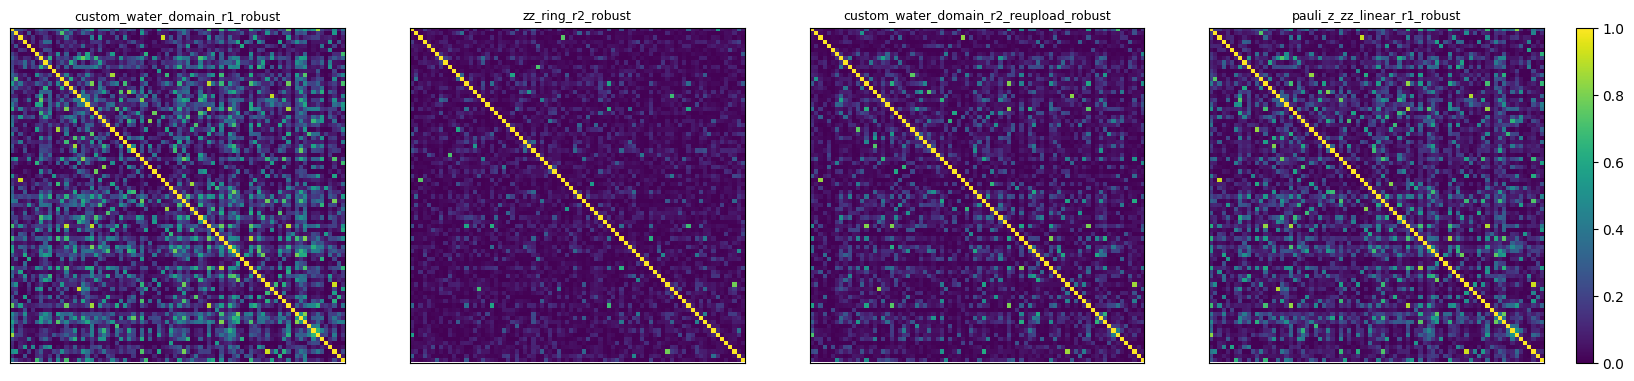

,map,family,f1_mean,balanced_accuracy_mean,alignment,intra_minus_inter,effective_rank,native_depth,native_2q_gates
0,custom_water_domain_r1_robust,custom_water_domain,0.623007,0.6250,0.048309,-0.003634,26.703147,24,10
1,zz_ring_r2_robust,ZZFeatureMap,0.607197,0.6250,0.106914,0.002966,63.635568,73,20
2,custom_water_domain_r2_reupload_robust,custom_water_domain,0.601531,0.6000,0.083936,0.001170,49.293320,48,20
3,pauli_z_zz_linear_r1_robust,PauliFeatureMap,0.576769,0.5875,0.056043,-0.003492,35.141809,31,8
4,zz_linear_r1_robust,ZZFeatureMap,0.576769,0.5875,0.056043,-0.003492,35.141809,31,8
5,pauli_z_zz_ring_r1_robust,PauliFeatureMap,0.569117,0.5875,0.058315,-0.003031,35.919721,38,10
6,zz_ring_r1_robust,ZZFeatureMap,0.569117,0.5875,0.058315,-0.003031,35.919721,38,10
7,zz_full_r1_robust,ZZFeatureMap,0.568889,0.5625,0.061386,-0.002712,36.288870,52,20
8,pauli_xz_xxzz_linear_r1_robust,PauliFeatureMap,0.558755,0.5500,0.037785,-0.004753,16.549156,42,14
9,pauli_z_zz_ring_r1_minmax,PauliFeatureMap,0.495686,0.5125,0.050226,-0.002222,23.263622,38,10


In [13]:
top_maps = best_by_map.head(4)["map"].tolist()
fig, axes = plt.subplots(1, len(top_maps), figsize=(4.2 * len(top_maps), 3.7), constrained_layout=True)
if len(top_maps) == 1:
    axes = [axes]
sort_idx = np.lexsort((folds, y))
for ax, map_name in zip(axes, top_maps):
    K = np.load(KERNEL_DIR / f"{map_name}_global_kernel.npy")
    im = ax.imshow(K[np.ix_(sort_idx, sort_idx)], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(map_name, fontsize=9)
    ax.set_xticks([])
    ax.set_yticks([])
fig.colorbar(im, ax=axes, fraction=0.025, pad=0.02)
fig.savefig(FIGURE_DIR / "top_map_heatmaps_comparison.png", dpi=160)
plt.show()

merged = (
    best_by_map
    .merge(geometry_summary, on=["map", "family", "scaling", "reps", "topology"], how="left")
    .merge(resource_summary[["map", "native_depth", "native_2q_gates", "native_2q_depth"]], on="map", how="left")
)
display(merged[[
    "map", "family", "f1_mean", "balanced_accuracy_mean", "alignment",
    "intra_minus_inter", "effective_rank", "native_depth", "native_2q_gates",
]].sort_values("f1_mean", ascending=False))

## 8. Sensibilidad a shots finitos y ruido proxy

La sensibilidad a shots se simula con muestreo binomial de cada entrada del kernel global exacto. La sensibilidad a ruido usa un proxy simple: contrae las similitudes off-diagonal hacia `1 / 2^n` y conserva la diagonal en 1 para mantener la escala del kernel. Esto no sustituye un modelo fisico de hardware, pero permite auditar robustez numerica antes de ir a H2 o a Guppy.

In [14]:
def sample_finite_shot_kernel(K: np.ndarray, shots: int, rng: np.random.Generator) -> np.ndarray:
    probs = np.clip(K, 0.0, 1.0)
    sampled = rng.binomial(shots, probs) / shots
    sampled = 0.5 * (sampled + sampled.T)
    np.fill_diagonal(sampled, 1.0)
    return sampled


def noisy_kernel_proxy(K: np.ndarray, n_qubits: int, noise_level: float) -> np.ndarray:
    uniform_overlap = 1.0 / (2 ** n_qubits)
    noisy = (1.0 - noise_level) * K + noise_level * uniform_overlap
    np.fill_diagonal(noisy, 1.0)
    return symmetrize_kernel(noisy)


rng = np.random.default_rng(RNG_SEED)
shot_rows = []
noise_rows = []

for row in best_by_map.itertuples(index=False):
    map_name = row.map
    C_best = float(row.C)
    K_exact = np.load(KERNEL_DIR / f"{map_name}_global_kernel.npy")

    for shots in SHOTS_GRID:
        repeat_metrics = []
        maes = []
        for repeat in range(N_SHOT_REPEATS):
            K_sampled = sample_finite_shot_kernel(K_exact, shots, rng)
            fold_df, _ = evaluate_precomputed_kernel(K_sampled, y, folds, C_best)
            repeat_metrics.append(summarize_fold_metrics(fold_df))
            maes.append(float(np.mean(np.abs(K_sampled - K_exact))))
        repeat_df = pd.DataFrame(repeat_metrics)
        shot_rows.append({
            "map": map_name,
            "C": C_best,
            "shots": shots,
            "repeats": N_SHOT_REPEATS,
            "kernel_mae_mean": float(np.mean(maes)),
            "kernel_mae_std": float(np.std(maes, ddof=1)),
            "f1_mean": float(repeat_df["f1_mean"].mean()),
            "f1_std_across_repeats": float(repeat_df["f1_mean"].std(ddof=1)),
            "balanced_accuracy_mean": float(repeat_df["balanced_accuracy_mean"].mean()),
            "accuracy_mean": float(repeat_df["accuracy_mean"].mean()),
        })

    for noise_level in NOISE_LEVELS:
        K_noisy = noisy_kernel_proxy(K_exact, N_QUBITS, noise_level)
        fold_df, _ = evaluate_precomputed_kernel(K_noisy, y, folds, C_best)
        summary = summarize_fold_metrics(fold_df)
        noise_rows.append({
            "map": map_name,
            "C": C_best,
            "noise_level": noise_level,
            "kernel_mae": float(np.mean(np.abs(K_noisy - K_exact))),
            **summary,
        })

shot_sensitivity = pd.DataFrame(shot_rows)
noise_sensitivity = pd.DataFrame(noise_rows)
shot_sensitivity.to_csv(ARTIFACT_DIR / "shot_sensitivity_summary.csv", index=False)
noise_sensitivity.to_csv(ARTIFACT_DIR / "noise_proxy_sensitivity_summary.csv", index=False)

display(shot_sensitivity.sort_values(["map", "shots"])[[
    "map", "shots", "kernel_mae_mean", "f1_mean", "f1_std_across_repeats", "balanced_accuracy_mean",
]])
display(noise_sensitivity.sort_values(["map", "noise_level"])[[
    "map", "noise_level", "kernel_mae", "f1_mean", "balanced_accuracy_mean", "mcc_mean",
]])

,map,shots,kernel_mae_mean,f1_mean,f1_std_across_repeats,balanced_accuracy_mean
0,custom_water_domain_r1_robust,256,0.009921,0.539370,0.066400,0.551250
1,custom_water_domain_r1_robust,1024,0.004991,0.558187,0.046385,0.585000
2,custom_water_domain_r1_robust,4096,0.002486,0.591910,0.036476,0.604375
6,custom_water_domain_r2_reupload_robust,256,0.007040,0.588432,0.027410,0.601250
7,custom_water_domain_r2_reupload_robust,1024,0.003547,0.582407,0.020307,0.596875
8,custom_water_domain_r2_reupload_robust,4096,0.001759,0.579255,0.016494,0.595625
24,pauli_xz_xxzz_linear_r1_robust,256,0.014065,0.491556,0.065124,0.502500
25,pauli_xz_xxzz_linear_r1_robust,1024,0.006995,0.539209,0.043217,0.533125
26,pauli_xz_xxzz_linear_r1_robust,4096,0.003500,0.577369,0.038610,0.565625
9,pauli_z_zz_linear_r1_robust,256,0.008738,0.558899,0.027634,0.566250


,map,noise_level,kernel_mae,f1_mean,balanced_accuracy_mean,mcc_mean
0,custom_water_domain_r1_robust,0.01,0.001401,0.655205,0.6500,0.306631
1,custom_water_domain_r1_robust,0.03,0.004204,0.643403,0.6500,0.304142
2,custom_water_domain_r1_robust,0.05,0.007007,0.587378,0.6125,0.228477
6,custom_water_domain_r2_reupload_robust,0.01,0.000623,0.566697,0.5875,0.174672
7,custom_water_domain_r2_reupload_robust,0.03,0.001870,0.566697,0.5875,0.174672
8,custom_water_domain_r2_reupload_robust,0.05,0.003117,0.566697,0.5875,0.174672
24,pauli_xz_xxzz_linear_r1_robust,0.01,0.002616,0.607937,0.6000,0.200000
25,pauli_xz_xxzz_linear_r1_robust,0.03,0.007847,0.636741,0.6125,0.227363
26,pauli_xz_xxzz_linear_r1_robust,0.05,0.013078,0.636945,0.6125,0.230319
9,pauli_z_zz_linear_r1_robust,0.01,0.000994,0.570103,0.5750,0.152430


## 9. Ablaciones: familia, topologia, repeticiones y escalado

### Por familia

,family,maps,best_f1,mean_f1,mean_alignment,mean_2q
0,PauliFeatureMap,4,0.576769,0.550082,0.050592,10.5
1,ZZFeatureMap,4,0.607197,0.580493,0.070664,14.5
2,custom_water_domain,2,0.623007,0.612269,0.066122,15.0


### Por topologia

,topology,maps,best_f1,mean_f1,mean_alignment,mean_2q
0,domain,2,0.623007,0.612269,0.066122,15.0
1,full,1,0.568889,0.568889,0.061386,20.0
2,linear,3,0.576769,0.570765,0.049957,10.0
3,ring,4,0.607197,0.560279,0.068442,12.5


### Por escalado

,scaling,maps,best_f1,mean_f1,mean_alignment
0,minmax,1,0.495686,0.495686,0.050226
1,robust_atan,9,0.623007,0.583461,0.063005


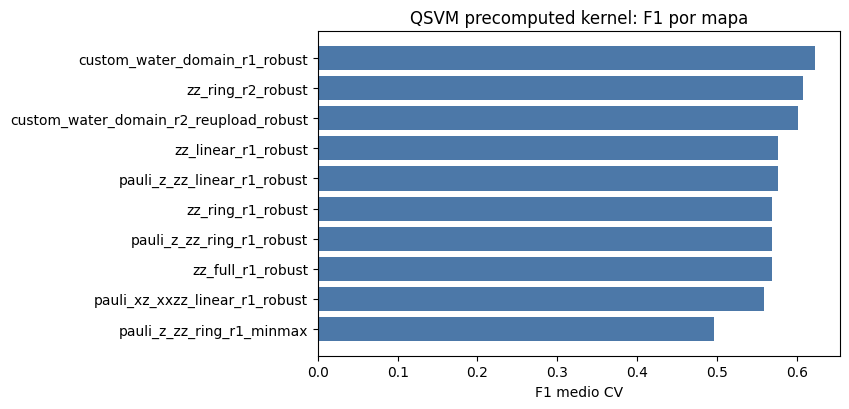

In [15]:
ablation = best_by_map.merge(
    geometry_summary[["map", "alignment", "intra_minus_inter", "effective_rank", "offdiag_std"]],
    on="map",
    how="left",
).merge(
    resource_summary[["map", "native_depth", "native_2q_gates"]],
    on="map",
    how="left",
)

family_summary = (
    ablation.groupby("family")
    .agg(
        maps=("map", "count"),
        best_f1=("f1_mean", "max"),
        mean_f1=("f1_mean", "mean"),
        mean_alignment=("alignment", "mean"),
        mean_2q=("native_2q_gates", "mean"),
    )
    .reset_index()
)
topology_summary = (
    ablation.groupby("topology")
    .agg(
        maps=("map", "count"),
        best_f1=("f1_mean", "max"),
        mean_f1=("f1_mean", "mean"),
        mean_alignment=("alignment", "mean"),
        mean_2q=("native_2q_gates", "mean"),
    )
    .reset_index()
)
scaling_summary = (
    ablation.groupby("scaling")
    .agg(
        maps=("map", "count"),
        best_f1=("f1_mean", "max"),
        mean_f1=("f1_mean", "mean"),
        mean_alignment=("alignment", "mean"),
    )
    .reset_index()
)

family_summary.to_csv(ARTIFACT_DIR / "ablation_by_family.csv", index=False)
topology_summary.to_csv(ARTIFACT_DIR / "ablation_by_topology.csv", index=False)
scaling_summary.to_csv(ARTIFACT_DIR / "ablation_by_scaling.csv", index=False)

display(Markdown("### Por familia"))
display(family_summary)
display(Markdown("### Por topologia"))
display(topology_summary)
display(Markdown("### Por escalado"))
display(scaling_summary)

fig, ax = plt.subplots(figsize=(8.6, 4.2))
plot_df = ablation.sort_values("f1_mean", ascending=True)
ax.barh(plot_df["map"], plot_df["f1_mean"], color="#4c78a8")
ax.set_xlabel("F1 medio CV")
ax.set_title("QSVM precomputed kernel: F1 por mapa")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "map_f1_ranking.png", dpi=160)
plt.show()

## 10. Manifiesto de ejecucion

In [16]:
best_map_row = best_by_map.iloc[0].to_dict()
manifest = {
    "input_artifacts": str(PART12_DIR),
    "output_artifacts": str(ARTIFACT_DIR),
    "pytket_version": pytket.__version__,
    "n_samples": int(len(df_q)),
    "n_qubits": int(N_QUBITS),
    "feature_set": EXPECTED_FEATURE_SET,
    "features": FEATURES,
    "domain_edges": DOMAIN_EDGES,
    "maps_evaluated": [config.__dict__ for config in MAP_CONFIGS],
    "C_grid": C_GRID,
    "shots_grid": SHOTS_GRID,
    "noise_levels": NOISE_LEVELS,
    "best_map_by_f1_mean": best_map_row,
    "notes": [
        "CV recomputa imputacion y escalado por fold.",
        "Figuras globales usan preprocesamiento global solo descriptivo.",
        "Ruido proxy no es un modelo fisico de hardware.",
        "Los pesos de DOMAIN_EDGES son hiperparametros heurísticos y deben someterse a ablacion.",
        "Resultados anteriores con Solids no son comparables con esta ejecucion chem5_v01.",
    ],
}
with (ARTIFACT_DIR / "parts_3_4_manifest.json").open("w", encoding="utf-8") as f:
    json.dump(manifest, f, indent=2)

display(Markdown(f"""
### Resultado principal

- Mejor mapa por F1 medio CV: `{best_map_row['map']}`.
- Familia: `{best_map_row['family']}`.
- `C={best_map_row['C']}`, F1 medio={best_map_row['f1_mean']:.3f}, exactitud balanceada media={best_map_row['balanced_accuracy_mean']:.3f}.
- Numero de qubits: `{N_QUBITS}`, uno por feature: `{', '.join(FEATURES)}`.
- Artefactos guardados en `{ARTIFACT_DIR}`.
"""))


### Resultado principal

- Mejor mapa por F1 medio CV: `custom_water_domain_r1_robust`.
- Familia: `custom_water_domain`.
- `C=10.0`, F1 medio=0.623, exactitud balanceada media=0.625.
- Numero de qubits: `5`, uno por feature: `Sulfate, ph, Conductivity, Chloramines, Hardness`.
- Artefactos guardados en `/content/drive/MyDrive/Colab Notebooks/artifacts_v3_4`.
